In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("Required Libraries have been loaded successfully  ")

Required Libraries have been loaded successfully  


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [30]:
df = pd.read_csv('/content/train.csv')
print("Data has been loaded successfully")
print("Shape:", df.shape)
print(df.head())
for column in df.columns.tolist():
  print(column)

Data has been loaded successfully
Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleTy

In [38]:
required_cols = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']
for col in required_cols:
    if col in df.columns:
            print(f"Column '{col}' exists")
    else:
            print(f"Column '{col}' doesn't exists-check the name properly ")

Column 'GrLivArea' exists
Column 'BedroomAbvGr' exists
Column 'FullBath' exists
Column 'SalePrice' exists


In [25]:
cols = ['GrLivArea','LotArea' , 'BedroomAbvGr', 'FullBath', 'SalePrice']
df = df[cols].dropna()
print("Columns have been selected and missing values have been removed.")
print(df.head())

Columns have been selected and missing values have been removed.
   GrLivArea  LotArea  BedroomAbvGr  FullBath  SalePrice
0       1710     8450             3         2     208500
1       1262     9600             3         2     181500
2       1786    11250             3         2     223500
3       1717     9550             3         1     140000
4       2198    14260             4         2     250000


In [26]:
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']
print("X aur y have been declared ")
print("X shape:", X.shape)
print("y shape:", y.shape)

X aur y have been declared 
X shape: (1460, 3)
y shape: (1460,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("The data has been split successfully.")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

The data has been split successfully.
Training rows: 1168
Testing rows: 292


In [24]:
model = LinearRegression()
model.fit(X_train, y_train)
print("The Model has been trained")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

The Model has been trained
Coefficients: [   104.02630701 -26655.16535734  30014.32410896]
Intercept: 52261.74862694461


In [ ]:
import pandas as pd
from IPython.display import display


y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred,
})

display(results)
metrics = pd.DataFrame({
      "Metric": ["R² Score", "RMSE"],
          "Value": [r2, rmse]
          })

display(metrics)

,Actual Price,Predicted Price
0,154500,113410.672553
1,325000,305081.877759
2,115000,135904.785630
3,159000,205424.675641
4,315500,227502.683490
...,...,...
287,89471,146619.495252
288,260000,191485.150502
289,189000,183787.203783
290,108000,132735.134895


,Metric,Value
0,R² Score,0.634119
1,RMSE,52975.717713


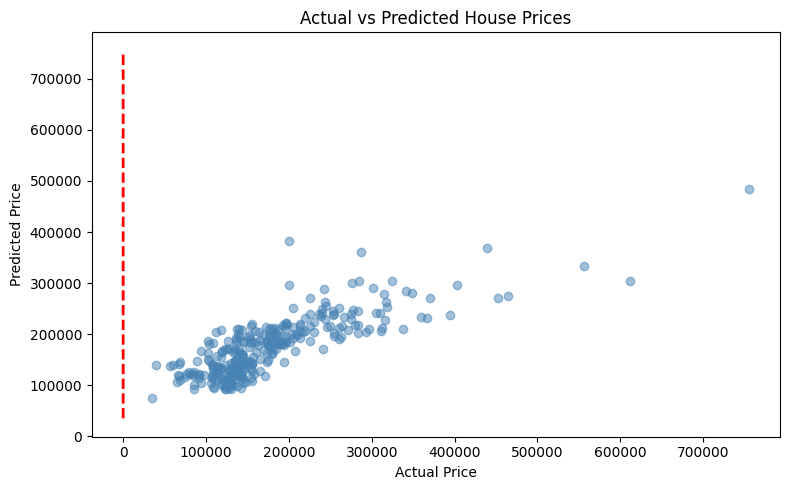

This is the graph of Predicted house prices Vs their actual price


In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.savefig('result.png')
plt.show()
print("This is the graph of Predicted house prices Vs their actual price")

In [ ]:
new_house = pd.DataFrame({'GrLivArea': [1500],'BedroomAbvGr': [3],'FullBath': [2]
})
price = model.predict(new_house)[0]
print(f"House which is of 1500 sqft, 3 bed and 2 bath → Predicted Price: ${price:,.0f}")

House which is of 1500 sqft, 3 bed and 2 bath → Predicted Price: $188,364
